In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
file = "C:/Users/khurs/Documents/GitHub/Load_Forecast_and_Balance/GLFN-TC/Datasets/NCENT-dataset/COAST.csv"
df = pd.read_csv(file)

# Exploratory Data Analysis

In [7]:
df.head()

,load,tempc,year,month,day,hour
0,8331.469266,2.976336,2002,1,1,0
1,8107.805431,6.029740,2002,1,1,1
2,7890.721717,7.391167,2002,1,1,2
3,7799.817527,7.079989,2002,1,1,3
4,7815.968171,4.057469,2002,1,1,4


In [8]:
print("--- First 5 Rows of the DataFrame ---")
print(df.head())
print("\n" + "="*100 + "\n")

print("--- DataFrame Info (Data Types and Non-Null Counts) ---")
df.info()
print("\n" + "="*100 + "\n")

print("--- Count of Missing Values per Column ---")
print(df.isnull().sum())
print("\n" + "="*100 + "\n")

print("--- Summary Statistics for Numerical Columns ---")
print(df.describe())

--- First 5 Rows of the DataFrame ---
          load     tempc  year  month  day  hour
0  8331.469266  2.976336  2002      1    1     0
1  8107.805431  6.029740  2002      1    1     1
2  7890.721717  7.391167  2002      1    1     2
3  7799.817527  7.079989  2002      1    1     3
4  7815.968171  4.057469  2002      1    1     4


--- DataFrame Info (Data Types and Non-Null Counts) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148920 entries, 0 to 148919
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   load    148920 non-null  float64
 1   tempc   148920 non-null  float64
 2   year    148920 non-null  int64  
 3   month   148920 non-null  int64  
 4   day     148920 non-null  int64  
 5   hour    148920 non-null  int64  
dtypes: float64(2), int64(4)
memory usage: 6.8 MB


--- Count of Missing Values per Column ---
load     0
tempc    0
year     0
month    0
day      0
hour     0
dtype: int64


--- Summary Statisti

In [9]:
df.head()

,load,tempc,year,month,day,hour
0,8331.469266,2.976336,2002,1,1,0
1,8107.805431,6.029740,2002,1,1,1
2,7890.721717,7.391167,2002,1,1,2
3,7799.817527,7.079989,2002,1,1,3
4,7815.968171,4.057469,2002,1,1,4


In [15]:
df['timestamp'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df['timestamp'] = pd.to_datetime(df['timestamp'])


In [16]:
print("--- Data type of 'date' column after correction ---")
print(df.dtypes)


--- Data type of 'date' column after correction ---
load                float64
tempc               float64
year                  int64
month                 int64
day                   int64
hour                  int64
timestamp    datetime64[ns]
dtype: object


In [17]:
# Check the first few rows to see the result
print("\n--- First 5 rows ---")
print(df.head())


--- First 5 rows ---
          load     tempc  year  month  day  hour           timestamp
0  8331.469266  2.976336  2002      1    1     0 2002-01-01 00:00:00
1  8107.805431  6.029740  2002      1    1     1 2002-01-01 01:00:00
2  7890.721717  7.391167  2002      1    1     2 2002-01-01 02:00:00
3  7799.817527  7.079989  2002      1    1     3 2002-01-01 03:00:00
4  7815.968171  4.057469  2002      1    1     4 2002-01-01 04:00:00


In [18]:
df.head()

,load,tempc,year,month,day,hour,timestamp
0,8331.469266,2.976336,2002,1,1,0,2002-01-01 00:00:00
1,8107.805431,6.029740,2002,1,1,1,2002-01-01 01:00:00
2,7890.721717,7.391167,2002,1,1,2,2002-01-01 02:00:00
3,7799.817527,7.079989,2002,1,1,3,2002-01-01 03:00:00
4,7815.968171,4.057469,2002,1,1,4,2002-01-01 04:00:00


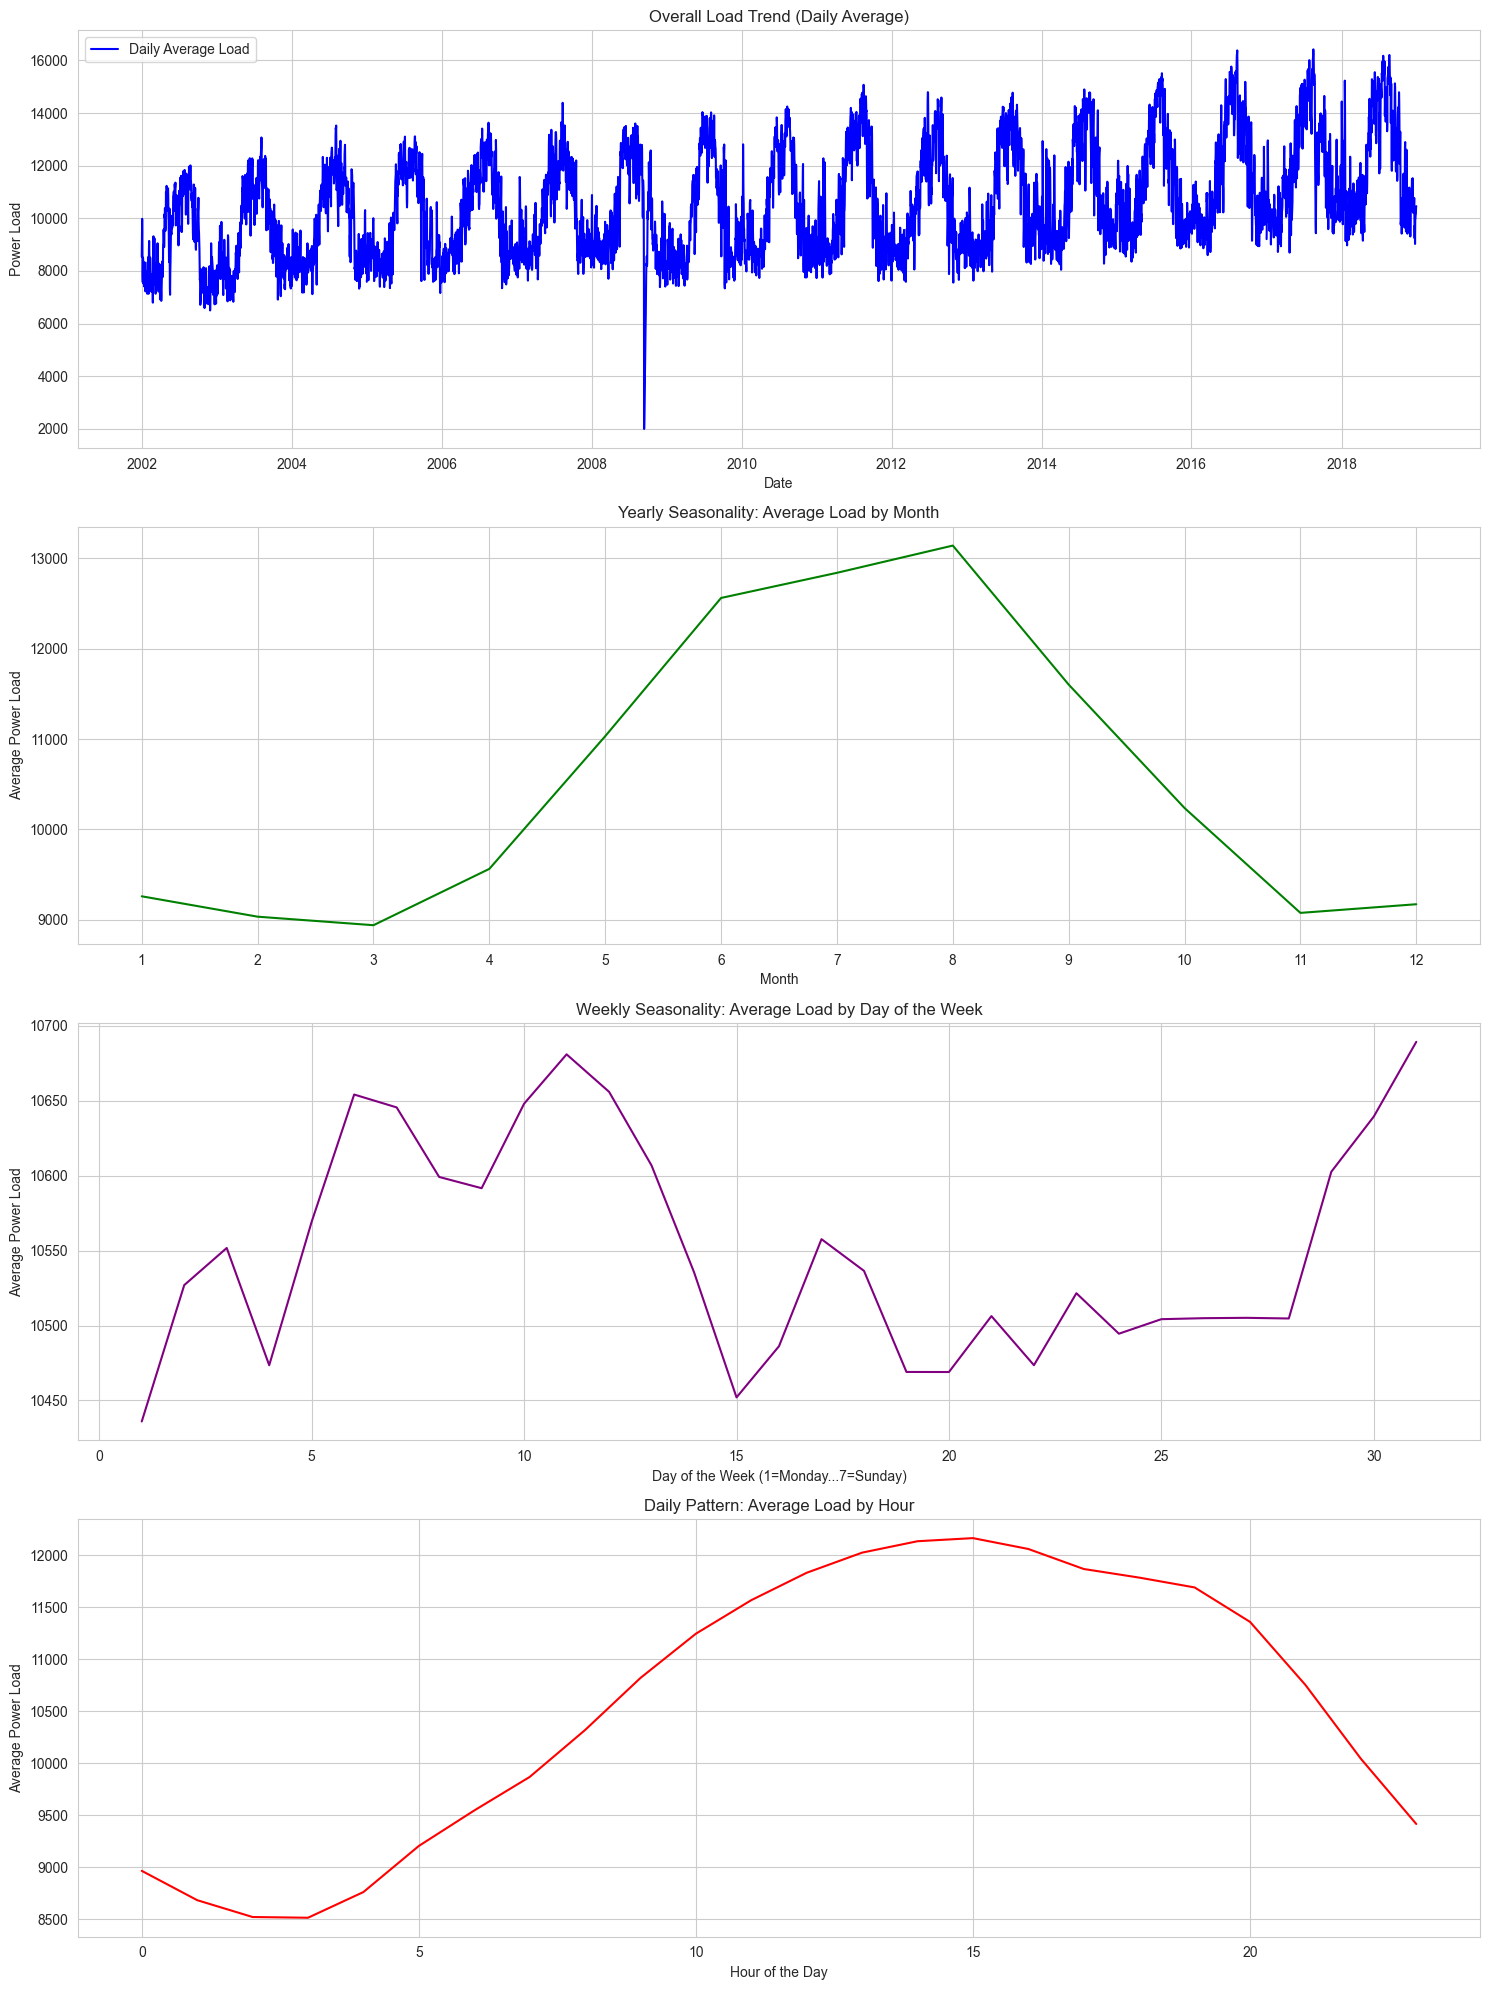

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Preparation ---

# Set the 'time' column as the index
df.set_index('timestamp', inplace=True)

# --- Plotting ---

# Set a style for the plots
sns.set_style("whitegrid")

# Create a figure with a 4x1 grid of subplots
fig, axes = plt.subplots(4, 1, figsize=(15, 20))

# --- 1. Overall Trend ---
# Updated column name for plotting
axes[0].plot(df['load'].resample('D').mean(), label='Daily Average Load', color='blue')
axes[0].set_title('Overall Load Trend (Daily Average)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Power Load')
axes[0].legend()

# --- 2. Yearly Seasonality (Monthly Pattern) ---
# Updated column names for plotting
sns.lineplot(x='month', y='load', data=df, ax=axes[1], errorbar=None, color='green')
axes[1].set_title('Yearly Seasonality: Average Load by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Power Load')
axes[1].set_xticks(range(1, 13))

# --- 3. Weekly Seasonality ---
# Updated column names and x-axis label
sns.lineplot(x='day', y='load', data=df, ax=axes[2], errorbar=None, color='purple')
axes[2].set_title('Weekly Seasonality: Average Load by Day of the Week')
axes[2].set_xlabel('Day of the Week (1=Monday...7=Sunday)')
axes[2].set_ylabel('Average Power Load')

# --- 4. Daily (Intraday) Pattern ---
# Updated column names for plotting
sns.lineplot(x='hour', y='load', data=df, ax=axes[3], errorbar=None, color='red')
axes[3].set_title('Daily Pattern: Average Load by Hour')
axes[3].set_xlabel('Hour of the Day')
axes[3].set_ylabel('Average Power Load')

# Adjust layout to prevent plots from overlapping
plt.tight_layout()
plt.show()

In [22]:
df.head(50)

,load,tempc,year,month,day,hour
timestamp,,,,,,
2002-01-01 00:00:00,8331.469266,2.976336,2002,1,1,0
2002-01-01 01:00:00,8107.805431,6.029740,2002,1,1,1
2002-01-01 02:00:00,7890.721717,7.391167,2002,1,1,2
2002-01-01 03:00:00,7799.817527,7.079989,2002,1,1,3
2002-01-01 04:00:00,7815.968171,4.057469,2002,1,1,4
2002-01-01 05:00:00,7978.538695,2.704030,2002,1,1,5
2002-01-01 06:00:00,8133.221200,2.057078,2002,1,1,6
2002-01-01 07:00:00,8136.470642,7.025792,2002,1,1,7
2002-01-01 08:00:00,8088.578682,1.363663,2002,1,1,8


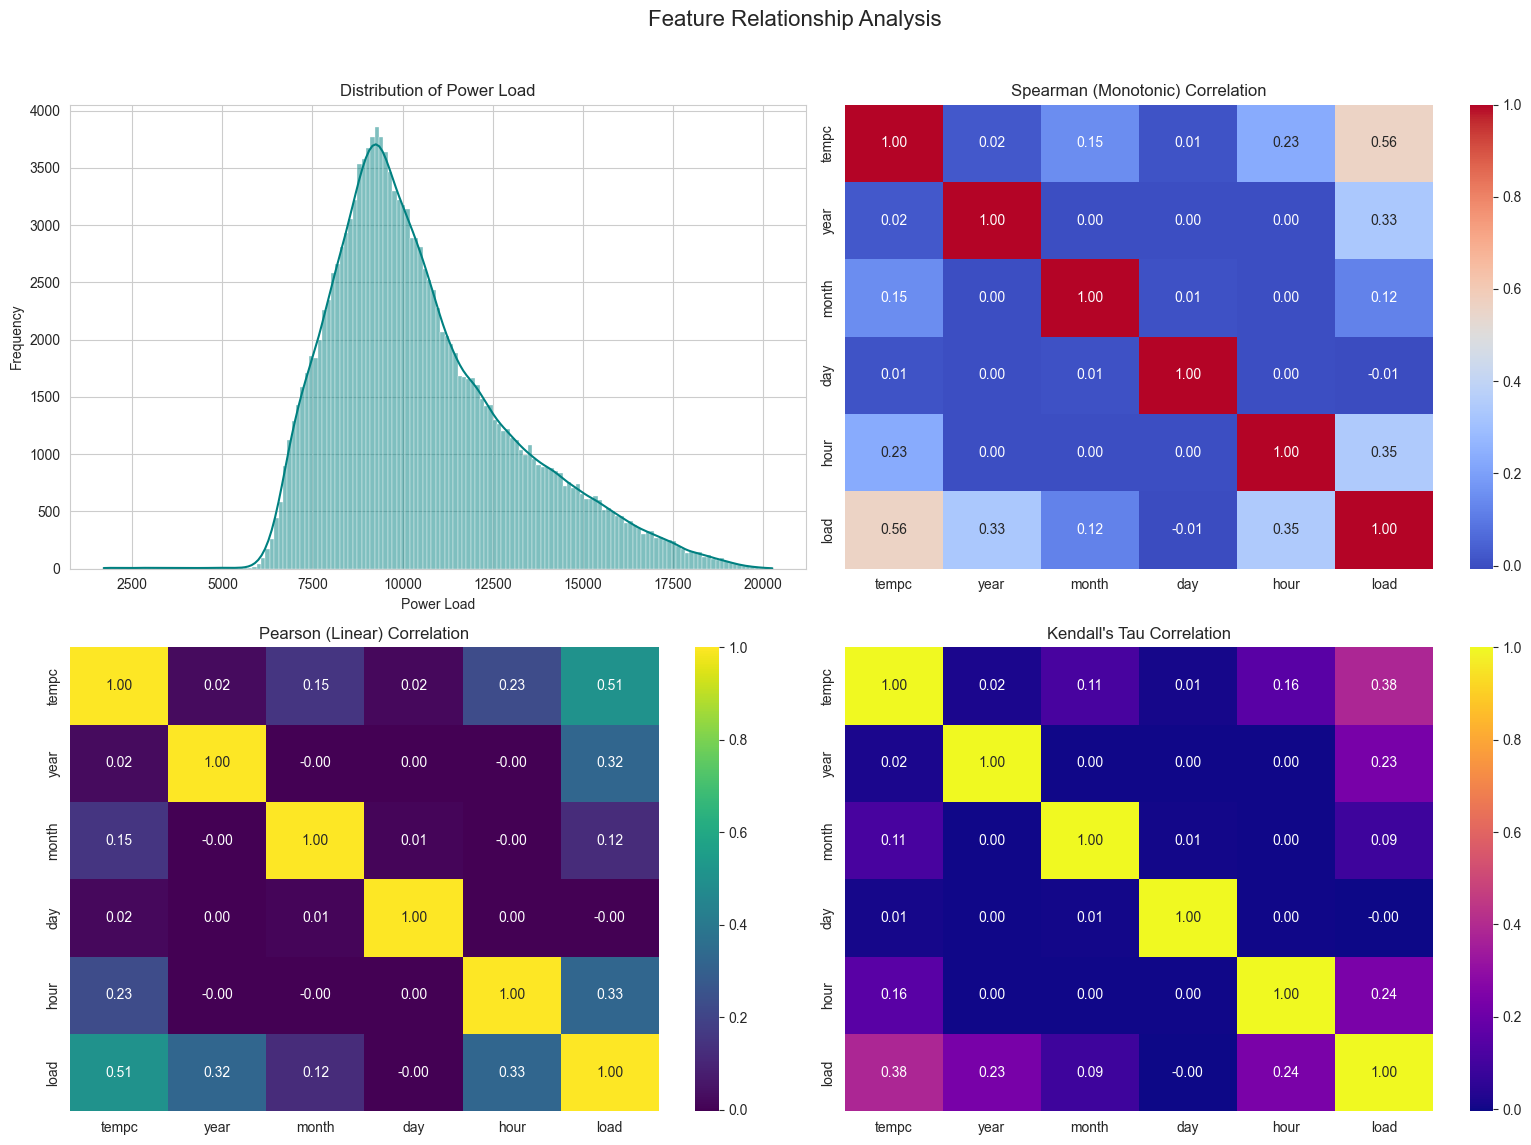

In [23]:
# Reset index to use 'date' and other columns easily in seaborn plots
# This undoes the set_index from the previous step, which is fine for these plots.
# df.reset_index(inplace=True)

# Set a style for the plots
sns.set_style("whitegrid")

# Create a figure with a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Feature Relationship Analysis', fontsize=16)

# --- 1. Distribution of Power Load (Top-Left) ---
sns.histplot(df['load'], kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Distribution of Power Load')
axes[0, 0].set_xlabel('Power Load')
axes[0, 0].set_ylabel('Frequency')

# --- Define columns for correlation matrices ---
# NOTE: 'temperature' is removed, and 'demand' is updated.
numerical_cols = ['tempc', 'year', 'month', 'day', 'hour', 'load']

# --- 2. Spearman Correlation Heatmap (Top-Right) ---
spearman_corr = df[numerical_cols].corr(method='spearman')
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Spearman (Monotonic) Correlation')

# --- 3. Pearson Correlation Heatmap (Bottom-Left) ---
pearson_corr = df[numerical_cols].corr(method='pearson')
sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='viridis', ax=axes[1, 0])
axes[1, 0].set_title('Pearson (Linear) Correlation')

# --- 4. Kendall's Tau Correlation Heatmap (Bottom-Right) ---
kendall_corr = df[numerical_cols].corr(method='kendall')
sns.heatmap(kendall_corr, annot=True, fmt='.2f', cmap='plasma', ax=axes[1, 1])
axes[1, 1].set_title("Kendall's Tau Correlation")

# Display the plots
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

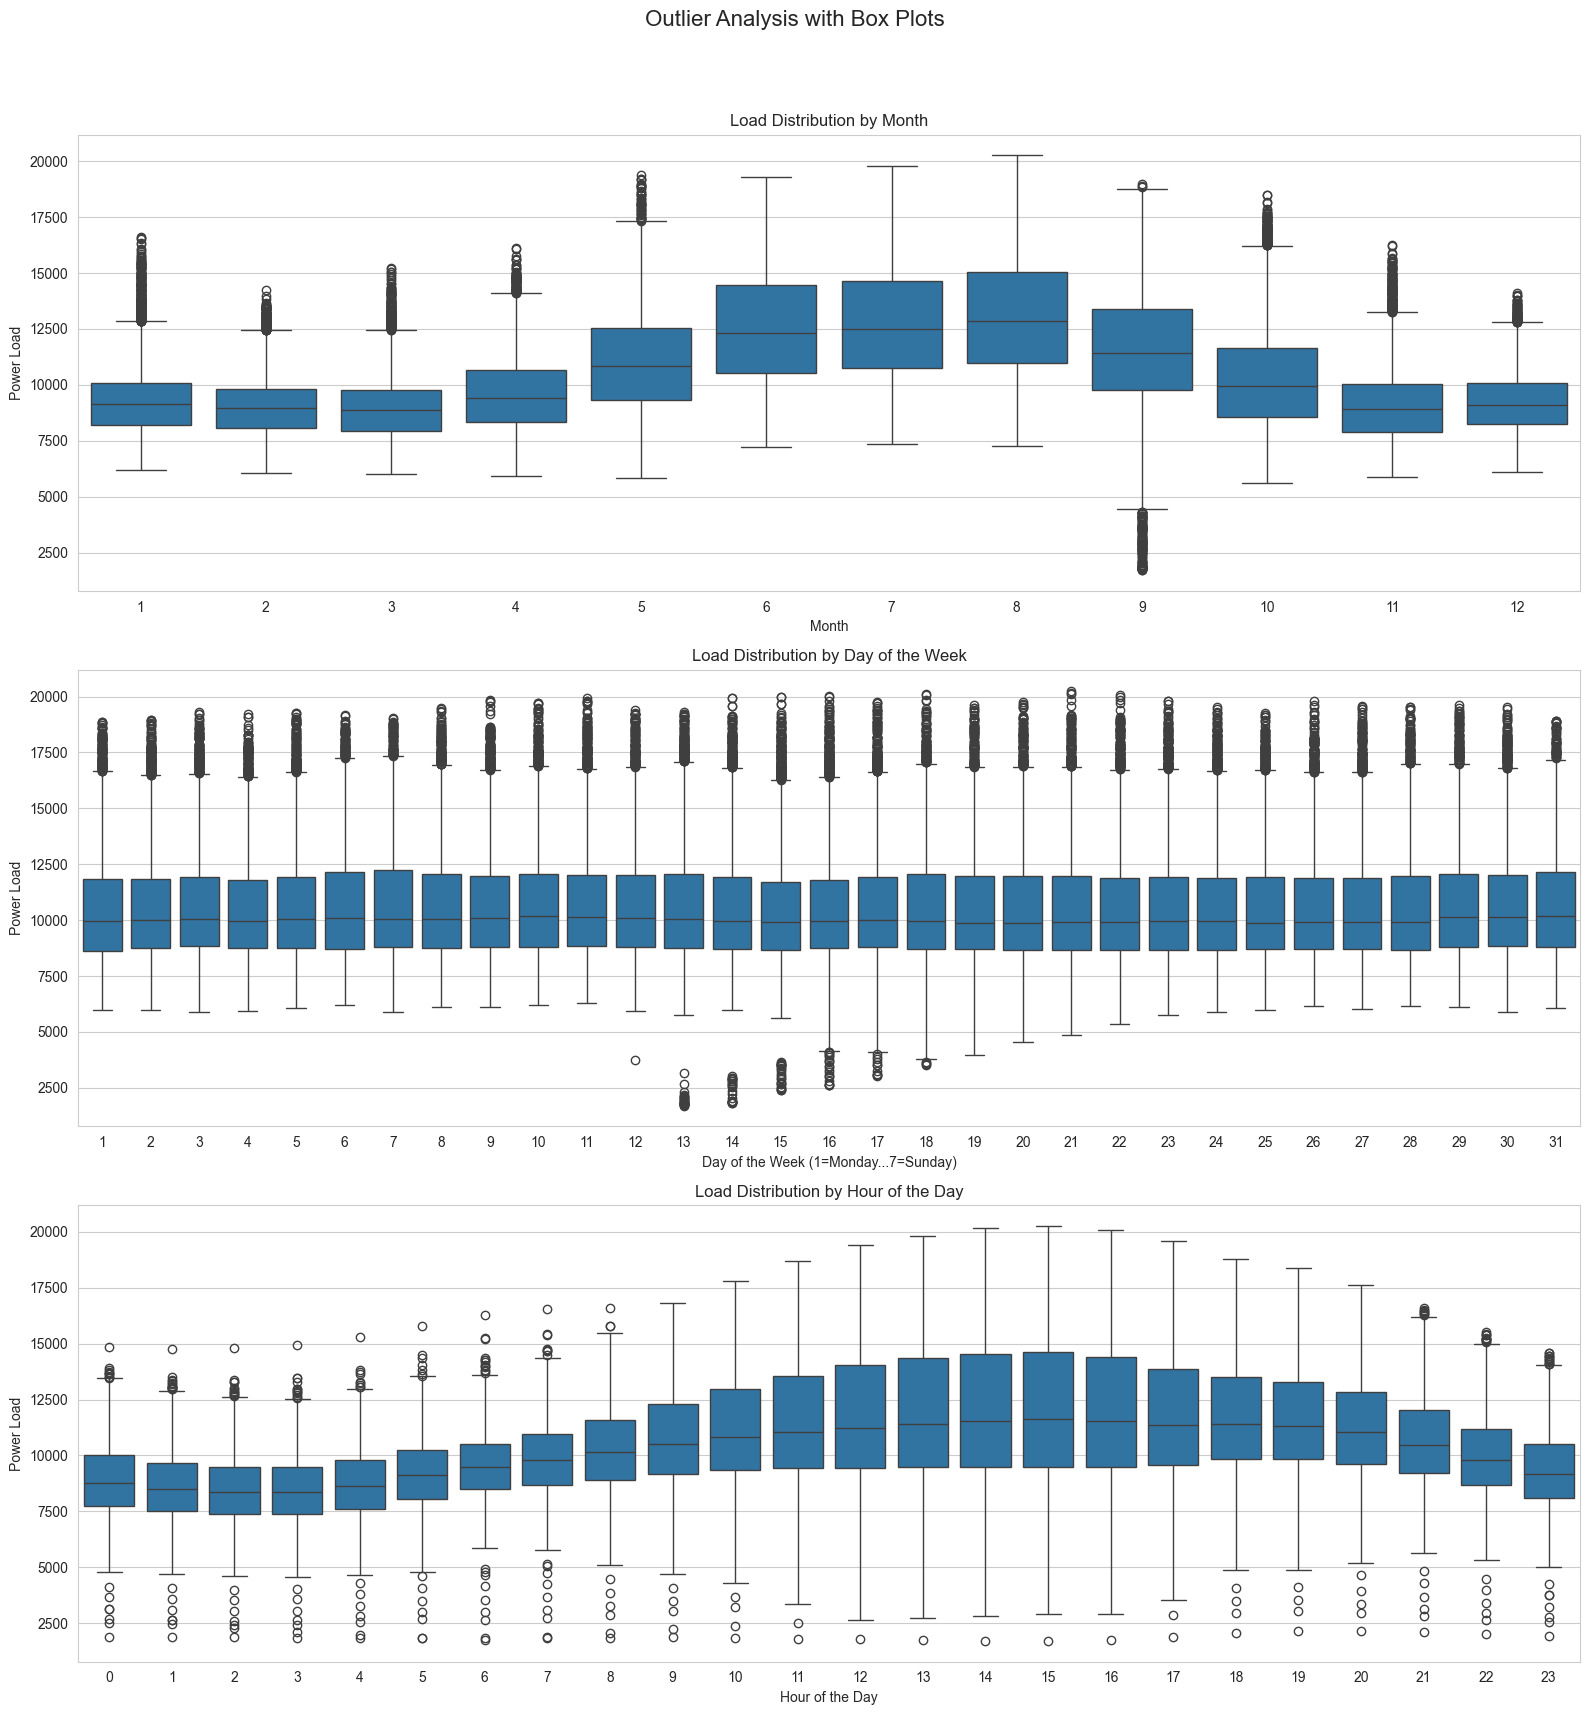

In [24]:
# --- Plotting ---

# Set the plot style
sns.set_style("whitegrid")

# Create a figure for our plots
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle('Outlier Analysis with Box Plots', fontsize=16)

# --- 1. Box Plot of Load by Month ---
# Updated 'y' parameter and y-axis label
sns.boxplot(x='month', y='load', data=df, ax=axes[0])
axes[0].set_title('Load Distribution by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Power Load')

# --- 2. Box Plot of Load by Weekday ---
# Updated 'y' parameter and labels
sns.boxplot(x='day', y='load', data=df, ax=axes[1])
axes[1].set_title('Load Distribution by Day of the Week')
axes[1].set_xlabel('Day of the Week (1=Monday...7=Sunday)')
axes[1].set_ylabel('Power Load')

# --- 3. Box Plot of Load by Hour ---
# Updated 'y' parameter and y-axis label
sns.boxplot(x='hour', y='load', data=df, ax=axes[2])
axes[2].set_title('Load Distribution by Hour of the Day')
axes[2].set_xlabel('Hour of the Day')
axes[2].set_ylabel('Power Load')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()